# Experiment Report

Read-only artifact notebook for the canonical `data/data_1to672.csv` workflow.
It only reads saved CSV, JSON, and PNG outputs from an experiment directory and is robust to partially regenerated report folders.


## Display Functions

In [1]:
from __future__ import annotations

import ast
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src').exists() and (candidate / 'README.md').exists():
            return candidate
    return start


def default_experiment_dir(root: Path) -> Path:
    canonical = root / 'results' / 'experiments' / 'data_tim_milan_10min_trainable_200_ctx144_h48' / 'q50_q95_seed42'
    if canonical.exists():
        return canonical
    candidates = sorted(
        (root / 'results' / 'experiments').glob('*/*'),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    return candidates[0] if candidates else canonical


def md(text: str) -> None:
    display(Markdown(text))


def note(text: str) -> None:
    md(f'> {text}')


def read_json(path: Path, quiet: bool = False):
    if not path.exists():
        if not quiet:
            note(f'Missing artifact: `{path.relative_to(ROOT) if path.is_absolute() and path.is_relative_to(ROOT) else path}`')
        return None
    return json.loads(path.read_text())


def read_csv(path: Path, quiet: bool = False):
    if not path.exists():
        if not quiet:
            note(f'Missing artifact: `{path.relative_to(ROOT) if path.is_absolute() and path.is_relative_to(ROOT) else path}`')
        return None
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        if not quiet:
            note(f'Artifact exists but is empty: `{path.relative_to(ROOT) if path.is_absolute() and path.is_relative_to(ROOT) else path}`')
        return None


def show_image_if_exists(path: Path, title: str) -> None:
    md(f'### {title}')
    if path.exists():
        display(Image(filename=str(path)))
    else:
        note(f'PNG artifact not available: `{path.relative_to(ROOT) if path.is_absolute() and path.is_relative_to(ROOT) else path}`')


def show_table(path: Path, title: str, rows: int = 10) -> None:
    md(f'### {title}')
    frame = read_csv(path)
    if frame is not None:
        display(frame.head(rows))


def normalize_dict_table(payload, index_name: str = 'key'):
    if payload is None:
        return None
    if isinstance(payload, dict):
        try:
            return pd.json_normalize(payload)
        except Exception:
            return pd.DataFrame([{index_name: key, 'value': value} for key, value in payload.items()])
    if isinstance(payload, list):
        return pd.DataFrame(payload)
    return pd.DataFrame([{index_name: 'value', 'value': payload}])


def parse_sequence(value):
    if isinstance(value, list):
        return [float(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.astype(float).tolist()
    if pd.isna(value):
        return []
    if isinstance(value, (int, float)):
        return [float(value)]
    if isinstance(value, str):
        text = value.strip()
        if not text:
            return []
        for parser in (json.loads, ast.literal_eval):
            try:
                parsed = parser(text)
                if isinstance(parsed, (list, tuple)):
                    return [float(item) for item in parsed]
            except Exception:
                continue
    return []


def discover_metric_rows(summary_path: Path, metrics_suffix: str) -> pd.DataFrame:
    summary = read_json(summary_path, quiet=True)
    rows: list[dict[str, object]] = []
    if isinstance(summary, dict):
        for split, split_payload in summary.get('splits', {}).items():
            for model_name, model_payload in split_payload.items():
                metrics_path = ROOT / model_payload['metrics_path']
                metrics = read_json(metrics_path, quiet=True)
                if isinstance(metrics, dict):
                    row = {'split': split, 'model': model_name, 'metrics_path': str(metrics_path.relative_to(ROOT))}
                    row.update(metrics)
                    rows.append(row)
    if not rows:
        for metrics_path in sorted(summary_path.parent.glob(f'*/{metrics_suffix}')):
            metrics = read_json(metrics_path, quiet=True)
            if isinstance(metrics, dict):
                row = {'metrics_path': str(metrics_path.relative_to(ROOT))}
                row.update(metrics)
                rows.append(row)
    return pd.DataFrame(rows)


def render_training_history(training_dir: Path) -> None:
    history_paths = sorted(training_dir.glob('*_history.json'))
    histories: dict[str, dict[str, list[float]]] = {}
    for path in history_paths:
        payload = read_json(path, quiet=True)
        if isinstance(payload, dict):
            histories[path.stem.replace('_history', '')] = payload
    if not histories:
        note('No training history JSON artifacts were found.')
        return

    metric_specs = [
        ('loss', 'Loss'),
        ('rmse', 'RMSE'),
        ('coverage', 'Coverage'),
        ('interval_width', 'Mean q95 - q50'),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    split_styles = {'train': '-', 'val': '--', 'test': ':'}
    for ax, (metric_key, title) in zip(axes.flat, metric_specs):
        plotted = False
        for model_name, history in histories.items():
            x_values = history.get('iteration') or list(range(1, max(len(history.get(f'train_{metric_key}', [])), 1) + 1))
            for split_name, linestyle in split_styles.items():
                values = history.get(f'{split_name}_{metric_key}', [])
                if not values:
                    continue
                plotted = True
                x = x_values[:len(values)] if len(x_values) >= len(values) else list(range(1, len(values) + 1))
                ax.plot(x, values, marker='o', linewidth=1.6, linestyle=linestyle, label=f'{model_name} {split_name}')
        ax.set_title(title)
        ax.set_xlabel('Iteration')
        ax.grid(alpha=0.3)
        if plotted:
            ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    display(fig)
    plt.close(fig)


def render_forecast_example(experiment_dir: Path, split: str = 'test') -> None:
    for model_name in ('chronos2', 'lstm', 'deepar', 'tft', 'seasonal_naive'):
        csv_path = experiment_dir / 'forecast_eval' / split / f'{model_name}_forecast_windows.csv'
        frame = read_csv(csv_path, quiet=True)
        if frame is None or frame.empty:
            continue
        row = frame.iloc[0]
        history = parse_sequence(row['history'])
        future = parse_sequence(row['future_true'])
        q50 = parse_sequence(row['y_pred_median'])
        q95 = parse_sequence(row['y_pred_95'])
        x_hist = np.arange(-len(history) + 1, 1)
        x_future = np.arange(1, len(future) + 1)
        fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
        ax.plot(x_hist, history, color='#4c566a', label='history')
        ax.plot(x_future, future, color='#2e7d32', label='future true')
        ax.plot(x_future, q50, color='#1f77b4', linewidth=1.8, label='q50')
        ax.plot(x_future, q95, color='#ff7f0e', linewidth=1.6, label='q95')
        if len(q50) == len(q95) == len(x_future):
            ax.fill_between(x_future, q50, q95, color='#ffbb78', alpha=0.25)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'Forecast Example | {model_name} | series={row["series"]} | start={int(row["start_index"])}')
        ax.set_xlabel('Relative step')
        ax.grid(alpha=0.3)
        ax.legend(ncol=4, fontsize=8)
        display(fig)
        plt.close(fig)
        return
    note(f'No forecast example window was found for split `{split}`.')


def render_system_example(experiment_dir: Path, split: str = 'test') -> None:
    for model_name in ('chronos2', 'lstm', 'deepar', 'tft', 'seasonal_naive'):
        csv_path = experiment_dir / 'system_eval' / split / f'{model_name}_system_windows.csv'
        frame = read_csv(csv_path, quiet=True)
        if frame is None or frame.empty:
            continue
        row = frame.iloc[0]
        history = parse_sequence(row['history'])
        future = parse_sequence(row['future_true'])
        q50 = parse_sequence(row['y_pred_median'])
        q95 = parse_sequence(row['y_pred_95'])
        tau_pred = int(row['tau_pred'])
        tau_true = int(row['tau_true'])
        safe_ceiling = float(row['safe_ceiling'])
        x_hist = np.arange(-len(history) + 1, 1)
        x_future = np.arange(1, len(future) + 1)
        fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
        ax.plot(x_hist, history, color='#4c566a', label='history')
        ax.plot(x_future, future, color='#2e7d32', label='future true')
        ax.plot(x_future, q50, color='#1f77b4', linewidth=1.8, label='q50')
        ax.plot(x_future, q95, color='#ff7f0e', linewidth=1.6, label='q95')
        if len(q50) == len(q95) == len(x_future):
            ax.fill_between(x_future, q50, q95, color='#ffbb78', alpha=0.25)
        ax.axvline(tau_pred, color='#d62728', linestyle='--', linewidth=1.4, label='tau_pred')
        ax.axvline(tau_true, color='#9467bd', linestyle=':', linewidth=1.6, label='tau_true')
        ax.axhline(safe_ceiling, color='#8c564b', linestyle='-.', linewidth=1.4, label='safe_ceiling')
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'Pipeline Example | {model_name} | series={row["series"]} | start={int(row["start_index"])}')
        ax.set_xlabel('Relative step')
        ax.grid(alpha=0.3)
        ax.legend(ncol=4, fontsize=8)
        display(fig)
        plt.close(fig)
        return
    note(f'No pipeline example window was found for split `{split}`.')


def render_cp_sweep_heatmap(experiment_dir: Path, split: str = 'val') -> None:
    summary_path = experiment_dir / 'cp_sweep' / split / 'cp_sweep_summary.csv'
    frame = read_csv(summary_path, quiet=True)
    if frame is None or frame.empty:
        note(f'No CP sweep summary was found for split `{split}`.')
        return
    models = list(dict.fromkeys(frame['model'].tolist()))
    fig, axes = plt.subplots(1, len(models), figsize=(5.2 * len(models), 4.5), squeeze=False, constrained_layout=True)
    for ax, model_name in zip(axes[0], models):
        subset = frame[frame['model'] == model_name].copy()
        pivot = subset.pivot_table(index='cp_min_size', columns='cp_penalty', values='MAE_CP', aggfunc='mean')
        image = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
        ax.set_title(model_name)
        ax.set_xlabel('cp_penalty')
        ax.set_ylabel('cp_min_size')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f'{value:g}' for value in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f'{value:g}' for value in pivot.index])
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                value = pivot.iloc[i, j]
                ax.text(j, i, f'{value:.2f}', ha='center', va='center', color='white', fontsize=9)
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    display(fig)
    plt.close(fig)


def render_calibrated_comparison(comparison_path: Path) -> None:
    frame = read_csv(comparison_path, quiet=True)
    if frame is None or frame.empty:
        note('No calibrated system-eval comparison artifact was found.')
        return
    metrics = ['MAE_CP', 'tolerance_hit_rate', 'coverage_rate', 'sharpness']
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
    for ax, metric in zip(axes.flat, metrics):
        raw_col = f'raw_{metric}' if f'raw_{metric}' in frame.columns else metric
        calibrated_col = f'calibrated_{metric}' if f'calibrated_{metric}' in frame.columns else None
        if calibrated_col is None or raw_col not in frame.columns:
            ax.text(0.5, 0.5, f'Missing columns for {metric}', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue
        positions = np.arange(len(frame))
        width = 0.35
        ax.bar(positions - width / 2, frame[raw_col], width=width, label='raw')
        ax.bar(positions + width / 2, frame[calibrated_col], width=width, label='calibrated')
        ax.set_xticks(positions)
        ax.set_xticklabels(frame['model'])
        ax.set_title(metric)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=8)
    display(fig)
    plt.close(fig)


ROOT = find_repo_root(Path.cwd().resolve())
if (ROOT / 'src').exists() and str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

EXPERIMENT_DIR_OVERRIDE = globals().get('EXPERIMENT_DIR_OVERRIDE', None)
EXPERIMENT_DIR = Path(EXPERIMENT_DIR_OVERRIDE) if EXPERIMENT_DIR_OVERRIDE else default_experiment_dir(ROOT)
if not EXPERIMENT_DIR.is_absolute():
    EXPERIMENT_DIR = (ROOT / EXPERIMENT_DIR).resolve()
REPORTS_DIR = EXPERIMENT_DIR / 'reports'
REPORT_INDEX_PATH = REPORTS_DIR / 'report_index.json'
REPORT_METADATA_PATH = REPORTS_DIR / 'report_metadata.json'
SYSTEM_EXAMPLE_PNG = REPORTS_DIR / 'example_windows_system_eval_test.png'
CALIBRATED_COMPARISON_PATH = EXPERIMENT_DIR / 'calibrated_system_eval' / 'calibrated_system_eval_comparison.csv'

REPORT_INDEX = read_json(REPORT_INDEX_PATH, quiet=True) or {}
REPORT_METADATA = read_json(REPORT_METADATA_PATH, quiet=True) or {}
FORECAST_INTERVAL_DEF = (
    REPORT_METADATA.get('forecast_metrics', {})
    .get('interval_width_mean', {})
    .get('definition', 'Mean one-sided forecast margin mean(q95 - q50) over all forecast horizon steps and windows.')
)

print(f'CWD: {Path.cwd().resolve()}')
print(f'Repo root: {ROOT}')
print(f'Experiment dir: {EXPERIMENT_DIR}')
print(f'Reports dir: {REPORTS_DIR}')
if not EXPERIMENT_DIR.exists():
    note('The resolved experiment directory does not exist. Set `EXPERIMENT_DIR_OVERRIDE` to a valid run folder and re-run this cell.')


CWD: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/notebooks
Repo root: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository
Experiment dir: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/experiments/data_tim_milan_10min_trainable_200_ctx144_h48/q50_q95_seed42
Reports dir: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/experiments/data_tim_milan_10min_trainable_200_ctx144_h48/q50_q95_seed42/reports


## Plots

In [2]:
md('## Overview')

status = read_json(REPORTS_DIR / 'stage_status.json', quiet=True)
if isinstance(status, dict) and status.get('stages'):
    display(pd.DataFrame(status['stages']).T)
else:
    note('`stage_status.json` is missing. The notebook will inspect raw artifact folders directly.')

report_index = read_json(REPORT_INDEX_PATH, quiet=True)
if isinstance(report_index, dict) and report_index:
    md('### Report Index')
    display(pd.DataFrame(sorted(report_index.items()), columns=['artifact', 'path']))

expected_paths = {
    'report_metadata.json': REPORT_METADATA_PATH,
    'example_windows_system_eval_test.png': SYSTEM_EXAMPLE_PNG,
    'calibrated_system_eval_comparison.csv': CALIBRATED_COMPARISON_PATH,
}
availability = pd.DataFrame(
    [{'artifact': name, 'exists': path.exists(), 'path': str(path.relative_to(ROOT))} for name, path in expected_paths.items()]
)
md('### Key Optional Artifacts')
display(availability)

manifest = read_json(EXPERIMENT_DIR / 'manifest.json', quiet=True)
if manifest is not None:
    md('### Manifest')
    display(normalize_dict_table(manifest))


## Overview

,status,started_at_utc,finished_at_utc,duration_sec,command,metrics,plots,report_index,published_plots
prepare_data,success,2026-03-22T20:08:50.288584+00:00,2026-03-22T20:08:50.782450+00:00,0.494,[/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Rep...,{'dataset_path': 'data/data_tim_milan_10min_tr...,{'split_summary_plot': 'results/experiments/da...,results/experiments/data_tim_milan_10min_train...,{'split_summary_plot': '/Users/colinminini/Des...
train,success,2026-03-22T20:08:50.782652+00:00,2026-03-22T20:11:22.764896+00:00,151.982,[/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Rep...,{'deepar': {'monitor_val_loss': 2.037356469714...,{'training_loss_plot': 'results/experiments/da...,results/experiments/data_tim_milan_10min_train...,{'split_summary_plot': '/Users/colinminini/Des...
forecast_eval,success,2026-03-22T20:11:22.765173+00:00,2026-03-22T20:15:29.322999+00:00,246.557,[/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Rep...,"{'val': {'chronos2': {'model': 'chronos2', 'sp...",{'forecast_eval_test_plot': 'results/experimen...,results/experiments/data_tim_milan_10min_train...,{'example_windows_chronos2_test_plot': '/Users...
system_eval,success,2026-03-22T17:46:02.782684+00:00,2026-03-22T17:50:36.951803+00:00,274.168,[/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Rep...,"{'test': {'chronos2': {'model': 'chronos2', 's...",{'system_eval_test_plot': 'results/experiments...,results/experiments/data_tim_milan_10min_train...,{'example_windows_chronos2_test_plot': '/Users...
cp_sweep,running,2026-03-23T08:42:42.655076+00:00,NaN,NaN,[/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Rep...,NaN,NaN,NaN,NaN
tau_calibration,running,2026-03-22T18:10:43.830884+00:00,NaN,NaN,[/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Rep...,NaN,NaN,NaN,NaN


### Report Index

,artifact,path
0,example_windows_chronos2_test_plot,results/experiments/data_tim_milan_10min_train...
1,example_windows_deepar_test_plot,results/experiments/data_tim_milan_10min_train...
2,example_windows_lstm_test_plot,results/experiments/data_tim_milan_10min_train...
3,example_windows_seasonal_naive_test_plot,results/experiments/data_tim_milan_10min_train...
4,example_windows_test_plot,results/experiments/data_tim_milan_10min_train...
5,example_windows_tft_test_plot,results/experiments/data_tim_milan_10min_train...
6,forecast_eval_test_plot,results/experiments/data_tim_milan_10min_train...
7,forecast_eval_val_plot,results/experiments/data_tim_milan_10min_train...
8,report_metadata,results/experiments/data_tim_milan_10min_train...
9,split_summary_plot,results/experiments/data_tim_milan_10min_train...


### Key Optional Artifacts

,artifact,exists,path
0,report_metadata.json,True,results/experiments/data_tim_milan_10min_train...
1,example_windows_system_eval_test.png,False,results/experiments/data_tim_milan_10min_train...
2,calibrated_system_eval_comparison.csv,False,results/experiments/data_tim_milan_10min_train...


### Manifest

,dataset_path,timestamp_col,cadence,random_seed,context_length,horizon,quantiles,train_ratio,val_ratio,test_ratio,num_rows,num_series,series_columns,created_at_utc,train_split.start_idx,train_split.end_idx,val_split.start_idx,val_split.end_idx,test_split.start_idx,test_split.end_idx
0,data/data_tim_milan_10min_trainable_200.csv,timestamp,10min,42,144,48,"[0.5, 0.95]",0.7,0.1,0.2,8928,200,"[MI1, MI2, MI3, MI4, MI5, MI6, MI7, MI8, MI9, ...",2026-03-22T20:08:50.673367+00:00,0,6249,6249,7142,7142,8928


## Prepare Data

### Split Summary

,split,start_idx,end_idx,num_rows
0,train,0,6249,6249
1,val,6249,7142,893
2,test,7142,8928,1786


### Saved Split Summary Plot

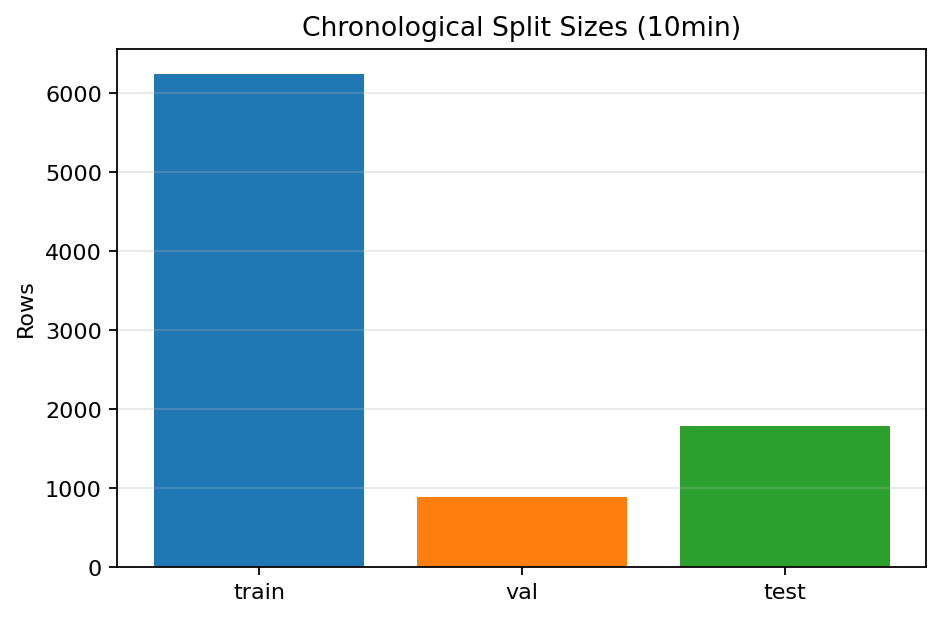

## Training

,manifest_path,device,models.deepar.history_path,models.deepar.checkpoint_path,models.deepar.max_iterations,models.deepar.patience_iterations,models.deepar.validate_every,models.deepar.train_window_step,models.deepar.training_schedule.steps_per_epoch,models.deepar.training_schedule.dense_train_windows,...,models.lstm.monitor_metrics.monitor_val_loss,models.lstm.monitor_metrics.monitor_val_rmse,models.lstm.monitor_metrics.val.rmse_q50,models.lstm.monitor_metrics.val.pinball_q50,models.lstm.monitor_metrics.val.pinball_q95,models.lstm.monitor_metrics.val.coverage_q95,models.lstm.monitor_metrics.val.interval_width_mean,models.lstm.monitor_metrics.best_val,models.lstm.monitor_metrics.last_iteration,models.lstm.monitor_metrics.monitor
0,results/experiments/data_tim_milan_10min_train...,mps,results/experiments/data_tim_milan_10min_train...,results/experiments/data_tim_milan_10min_train...,171,2561,171,6,3232,1211600,...,1.105571,6.938748,6.938748,1.715316,0.495882,0.975785,8.63802,1.105571,167,loss


### Training Curves

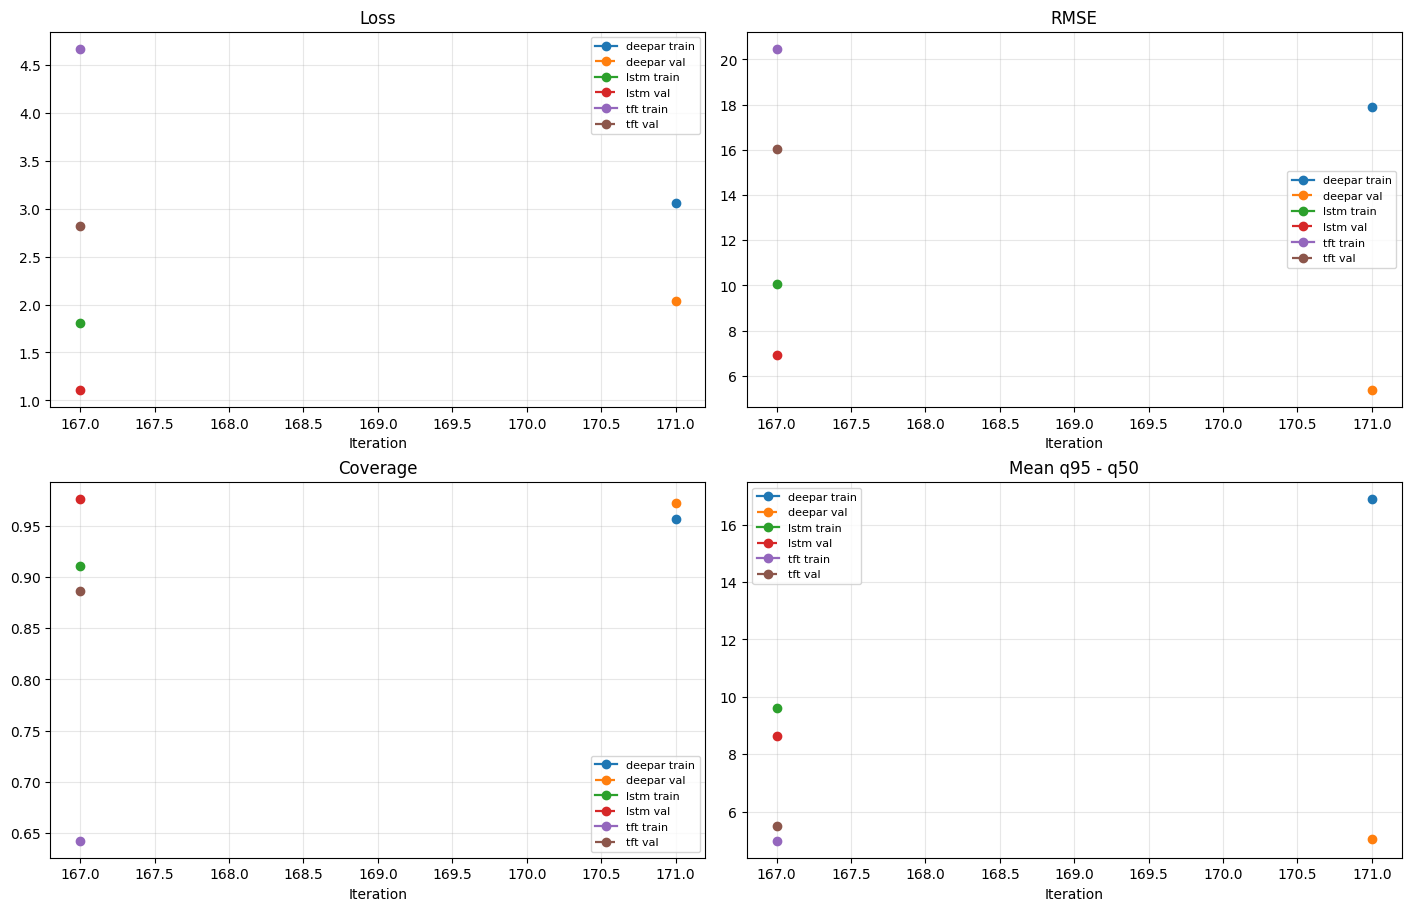

### Saved Training Loss PNG

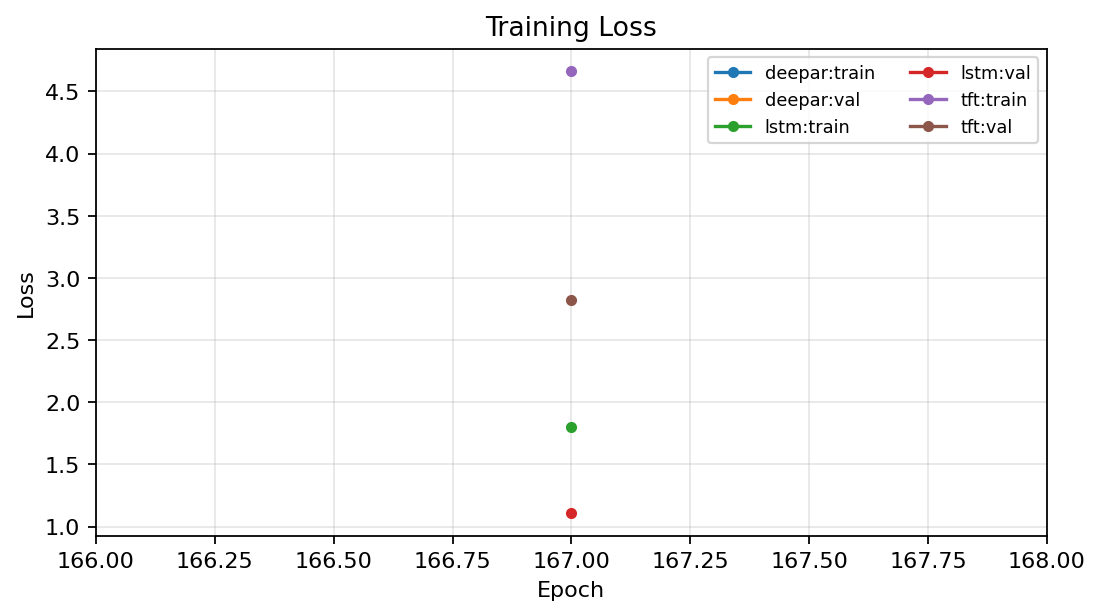

In [3]:
md('## Prepare Data')
show_table(EXPERIMENT_DIR / 'split_summary.csv', 'Split Summary')
show_image_if_exists(REPORTS_DIR / 'prepare_data_split_summary.png', 'Saved Split Summary Plot')

md('## Training')
training_summary = read_json(EXPERIMENT_DIR / 'training' / 'training_summary.json', quiet=True)
if training_summary is not None:
    display(normalize_dict_table(training_summary))
md('### Training Curves')
render_training_history(EXPERIMENT_DIR / 'training')
show_image_if_exists(REPORTS_DIR / 'training_loss.png', 'Saved Training Loss PNG')


## Forecast Evaluation

,split,model,num_windows_total,rmse_q50,pinball_q50,pinball_q95,coverage_q95,interval_width_mean
0,test,chronos2,7400,7.070477,2.108417,0.728333,0.813936,6.545527
1,test,deepar,7400,18.966266,5.963192,2.415715,0.357691,10.274786
2,test,lstm,7400,7.452172,1.968146,0.491407,0.895113,7.013062
3,test,seasonal_naive,7400,7.262978,1.404979,0.488935,0.857810,4.497222
4,test,tft,7400,14.423095,2.385968,2.451473,0.913916,5.449045
5,val,chronos2,3600,7.229148,1.687570,0.521602,0.949323,8.097793
6,val,deepar,3600,20.758449,6.481838,2.789145,0.340764,10.949068
7,val,lstm,3600,8.515828,2.112703,0.608390,0.882517,7.525870
8,val,seasonal_naive,3600,7.587165,1.472632,0.521552,0.854549,5.072770
9,val,tft,3600,16.040489,2.666536,2.950900,0.885596,5.504144


**Forecast Interval Width**: Mean one-sided forecast margin mean(q95 - q50) over all forecast horizon steps and windows.

### Saved Forecast Metric Plot (test)

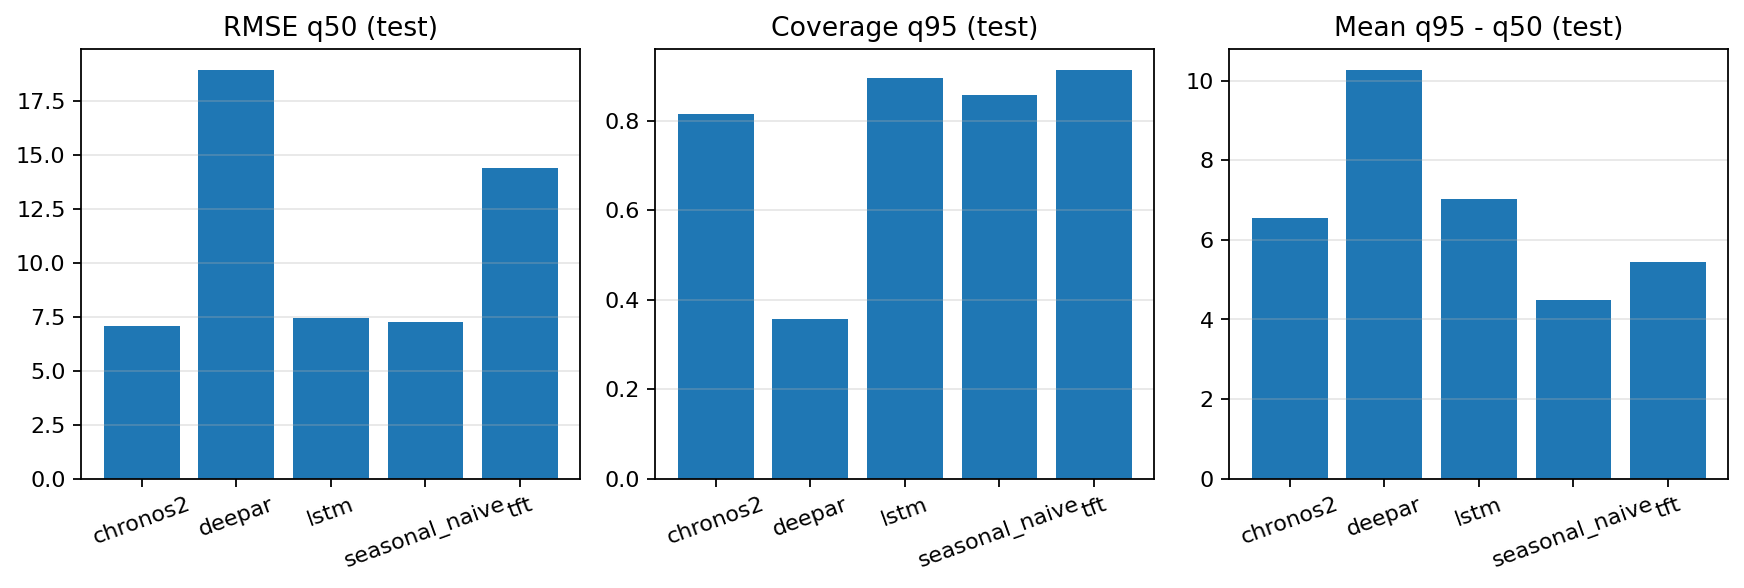

### Forecast Example Window

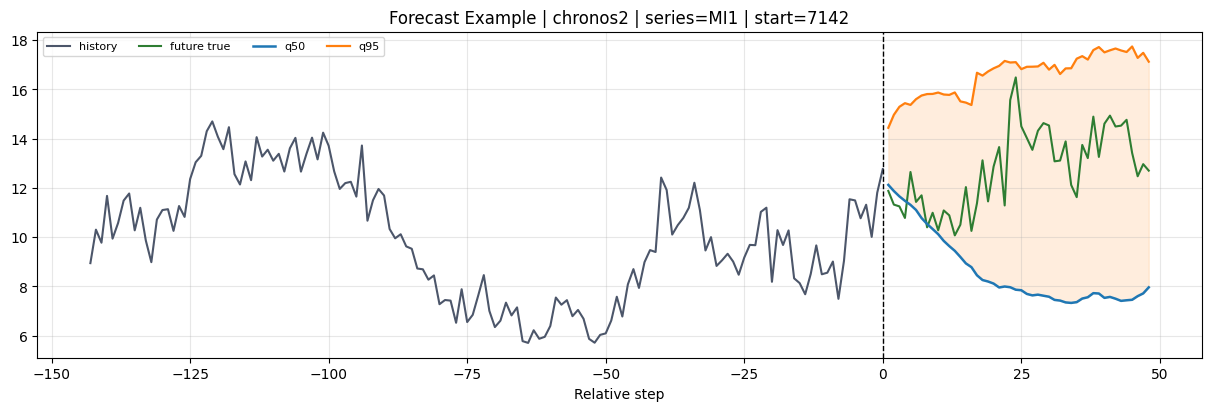

In [4]:
md('## Forecast Evaluation')
forecast_metrics = discover_metric_rows(EXPERIMENT_DIR / 'forecast_eval' / 'forecast_eval_summary.json', '*_forecast_metrics.json')
if not forecast_metrics.empty:
    ordered_columns = [
        'split', 'model', 'num_windows_total', 'rmse_q50', 'pinball_q50', 'pinball_q95', 'coverage_q95', 'interval_width_mean'
    ]
    existing_columns = [column for column in ordered_columns if column in forecast_metrics.columns]
    display(forecast_metrics[existing_columns].sort_values(['split', 'model']).reset_index(drop=True))
else:
    note('No forecast metric JSON artifacts were found.')

md(f'**Forecast Interval Width**: {FORECAST_INTERVAL_DEF}')
show_image_if_exists(REPORTS_DIR / 'forecast_eval_test.png', 'Saved Forecast Metric Plot (test)')
md('### Forecast Example Window')
render_forecast_example(EXPERIMENT_DIR, split='test')
#show_image_if_exists(REPORTS_DIR / 'example_windows_test.png', 'Saved Forecast Example PNG')


In [5]:
md('## System Evaluation')
system_metrics = discover_metric_rows(EXPERIMENT_DIR / 'system_eval' / 'system_eval_summary.json', '*_system_metrics.json')
if not system_metrics.empty:
    ordered_columns = ['split', 'model', 'num_windows_total', 'MAE_CP', 'tolerance', 'tolerance_hit_rate', 'coverage_rate', 'sharpness']
    existing_columns = [column for column in ordered_columns if column in system_metrics.columns]
    display(system_metrics[existing_columns].sort_values(['split', 'model']).reset_index(drop=True))
else:
    note('No system metric JSON artifacts were found.')

show_image_if_exists(REPORTS_DIR / 'system_eval_test.png', 'Saved System Metric Plot (test)')
md('### Pipeline Example Window')
render_system_example(EXPERIMENT_DIR, split='test')
#show_image_if_exists(REPORTS_DIR / 'example_windows_system_eval_test.png', 'Saved Pipeline Example PNG')

md('## Change-Point Sweep')
show_table(EXPERIMENT_DIR / 'cp_sweep' / 'val' / 'cp_sweep_summary.csv', 'CP Sweep Summary')
md('### CP Sweep Heatmap')
render_cp_sweep_heatmap(EXPERIMENT_DIR, split='val')
#show_image_if_exists(REPORTS_DIR / 'cp_sweep_val.png', 'Saved CP Sweep Heatmap PNG')


## System Evaluation

> No system metric JSON artifacts were found.

### Saved System Metric Plot (test)

> PNG artifact not available: `results/experiments/data_tim_milan_10min_trainable_200_ctx144_h48/q50_q95_seed42/reports/system_eval_test.png`

### Pipeline Example Window

...

## Change-Point Sweep

### CP Sweep Summary

> Missing artifact: `results/experiments/data_tim_milan_10min_trainable_200_ctx144_h48/q50_q95_seed42/cp_sweep/val/cp_sweep_summary.csv`

### CP Sweep Heatmap

> No CP sweep summary was found for split `val`.

In [6]:
md('## Tau Calibration')
summary_path = EXPERIMENT_DIR / 'tau_calibration' / 'tau_calibration_summary.csv'
best_rows_path = EXPERIMENT_DIR / 'tau_calibration' / 'tau_calibration_best_test_rows.csv'
if summary_path.exists():
    show_table(summary_path, 'Tau Calibration Summary')
    show_table(best_rows_path, 'Tau Calibration Best Test Rows')
    show_image_if_exists(REPORTS_DIR / 'tau_calibration_test.png', 'Saved Tau Calibration Plot')
    show_image_if_exists(REPORTS_DIR / 'tau_calibration_feature_importance.png', 'Saved Tau Calibration Feature Importance PNG')
else:
    note('Tau calibration is optional and is not part of the default run. Use `--with-tau-calibration` to generate these artifacts.')

md('## Calibrated System Evaluation')
if CALIBRATED_COMPARISON_PATH.exists():
    show_table(CALIBRATED_COMPARISON_PATH, 'Raw vs Calibrated System Metrics')
    md('### Raw vs Calibrated Comparison')
    render_calibrated_comparison(CALIBRATED_COMPARISON_PATH)
    show_image_if_exists(REPORTS_DIR / 'calibrated_system_eval_test.png', 'Saved Calibrated System Eval PNG')
else:
    note('Calibrated system-eval artifacts are absent for this run. Re-run the pipeline with `--with-tau-calibration` to materialize them.')


## Tau Calibration

> Tau calibration is optional and is not part of the default run. Use `--with-tau-calibration` to generate these artifacts.

## Calibrated System Evaluation

> Calibrated system-eval artifacts are absent for this run. Re-run the pipeline with `--with-tau-calibration` to materialize them.